In [23]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [24]:
image = cv2.imread('shapes.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


### **Finding Contours as per usual**

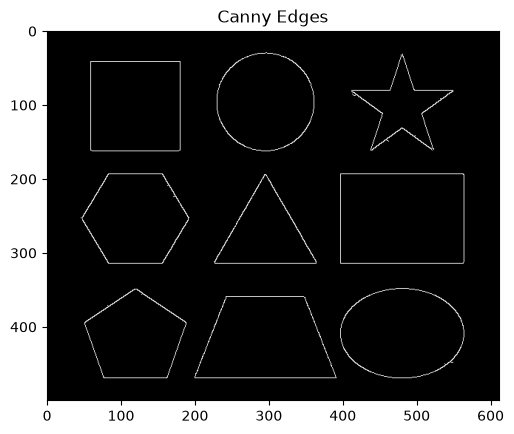

Number of contours found =  11


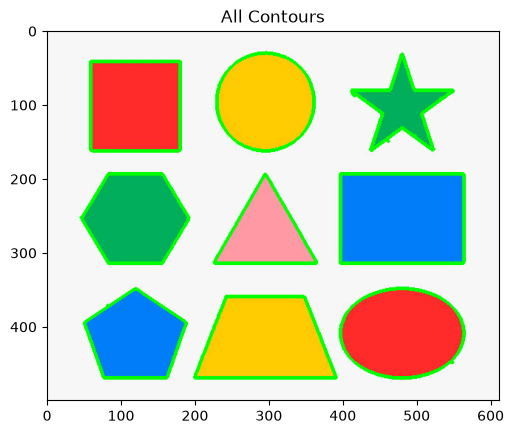

In [25]:
# Grayscale our image
gray = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)

# Find Canny edges
edged = cv2.Canny(gray, 50, 200)
plt.imshow(edged, cmap='gray')
plt.title('Canny Edges')
plt.show()

# Find contours and print how many were found
contours, hierarchy = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
print("Number of contours found = ", len(contours))

# Draw all contours over blank image
cv2.drawContours(image, contours, -1, (0,255,0), 3)
plt.imshow(image)
plt.title('All Contours')
plt.show()

In [7]:
# def get_contour_areas(contours):
#     """returns the areas of all contours as list"""
#     all_areas = []
#     for cnt in contours:
#         area = cv2.contourArea(cnt)
#         all_areas.append(area)
#     return all_areas

# # Load our image
# image = cv2.imread('shapes.jpg')
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# # Let's print the areas of the contours before sorting
# print("Contor Areas before sorting...")
# print(get_contour_areas(contours))
# gray_img = cv2.cvtColor(image,cv2.COLOR_RGB2GRAY)
# _, thresh = cv2.threshold(
#     gray_img,
#     0,
#     255,
#     cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
# )


# contours, hierarchy = cv2.findContours(
#     thresh,
#     cv2.RETR_EXTERNAL,
#     cv2.CHAIN_APPROX_SIMPLE
# )

# # Sort contours large to small by area
# sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

# print("Contor Areas after sorting...") 
# print(get_contour_areas(sorted_contours))

# # Iterate over our contours and draw one at a time
# for (i,c) in enumerate(sorted_contours):
#     M = cv2.moments(c)
#     if M["m00"] != 0:
#         cx = int(M['m10'] / M['m00'])
#         cy = int(M['m01'] / M['m00'])
#         cv2.putText(image, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 0), 3)
#         cv2.drawContours(image, [c], -1, (255,0,0), 3)


# plt.imshow(image)
# plt.title('Contours by area')
# plt.show()

Contour Areas before sorting...
[0.0, 0.0, 0.0, 0.0, 16577.0, 0.0, 16036.0, 11742.0, 0.0, 8446.0, 13293.0, 20212.0, 0.0, 0.0, 0.0, 0.0, 14643.5, 6161.5, 13993.5]
Contour Areas after sorting...
[20212.0, 16577.0, 16036.0, 14643.5, 13993.5, 13293.0, 11742.0, 8446.0, 6161.5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


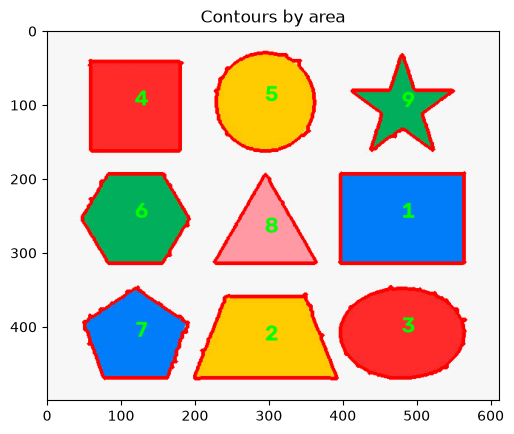

In [26]:
def get_contour_areas(contours):
    return [cv2.contourArea(cnt) for cnt in contours]

# Load image
image = cv2.imread('shapes.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# --- KEY FIX: use HSV saturation channel instead of grayscale ---
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
saturation = hsv[:, :, 1]

# Background is low-saturation (grayish), shapes are high-saturation (colorful)
_, thresh = cv2.threshold(saturation, 30, 255, cv2.THRESH_BINARY)

# Optional: clean up small gaps/noise
kernel = np.ones((5, 5), np.uint8)
thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)

# Find contours
contours, hierarchy = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Contour Areas before sorting...")
print(get_contour_areas(contours))

# Sort contours large to small by area
sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)

print("Contour Areas after sorting...")
print(get_contour_areas(sorted_contours))

# Draw and label each contour by centroid
for (i, c) in enumerate(sorted_contours):
    M = cv2.moments(c)
    if M["m00"] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(image, str(i + 1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        cv2.drawContours(image, [c], -1, (255, 0, 0), 3)

plt.imshow(image)
plt.title('Contours by area')
plt.show()

In [31]:
def x_cord_contour(contour):

    M = cv2.moments(contour)

    if M["m00"] != 0:
        return int(M["m10"] / M["m00"])

    return 0

def label_contour_center(image, c):
    """Places a red circle on the centers of contours"""
    M = cv2.moments(c)
    if M["m00"] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])

    # Draw the countour number on the image
        cv2.circle(image,(cx,cy), 10, (0,0,255), -1)
        return image

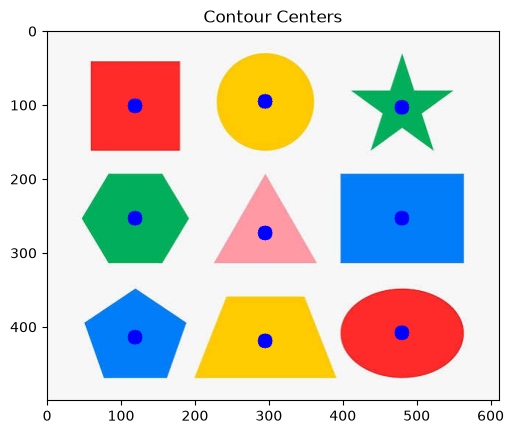

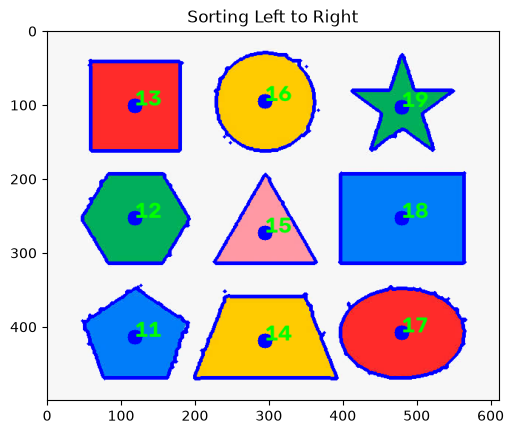

In [32]:

image_o = cv2.imread('shapes.jpg')
image_o = cv2.cvtColor(image_o, cv2.COLOR_BGR2RGB)
original_image = image_o.copy()

# Computer Center of Mass or centroids and draw them on our image
for (i, c) in enumerate(contours):
    orig = label_contour_center(original_image, c)

# Showing the Contour centers
plt.imshow(original_image)
plt.title('Contour Centers')
plt.show()

# Sort by left to right using our x_cord_contour function
contours_left_to_right = sorted(contours, key = x_cord_contour, reverse = False)

# Labeling Contours left to right
for (i,c)  in enumerate(contours_left_to_right):
    cv2.drawContours(original_image, [c], -1, (0,0,255), 3)
    M = cv2.moments(c)
    if M["m00"] != 0:
        cx = int(M['m10'] / M['m00'])
        cy = int(M['m01'] / M['m00'])
        cv2.putText(original_image, str(i+1), (cx, cy), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 3)
        (x, y, w, h) = cv2.boundingRect(c)

plt.imshow(original_image)
plt.title('Sorting Left to Right')
plt.show()

## **Approximating Contours using ApproxPolyDP**

### **Using ApproxPolyDP to approximate contours as a more defined shape**
It approximates a contour shape to another shape with less number of vertices depending upon the precision we specify.


***cv2.approxPolyDP(contour, Approximation Accuracy, Closed)***
- **contour** – is the individual contour we wish to approximate
- **Approximation Accuracy** – Important parameter is determining the accuracy of the approximation. Small values give precise-  approximations, large values give more generic approximation. A good rule of thumb is less than 5% of the contour perimeter
- **Closed** – a Boolean value that states whether the approximate contour should be open or closed 


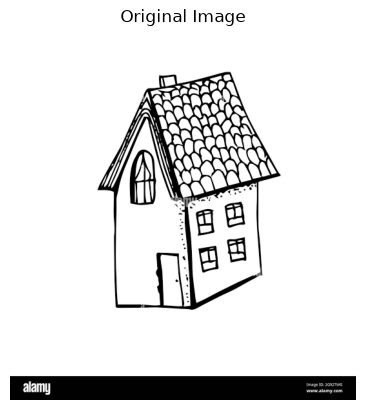

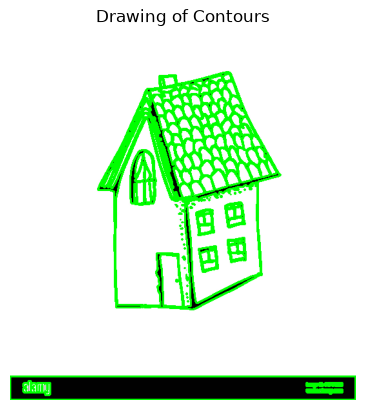

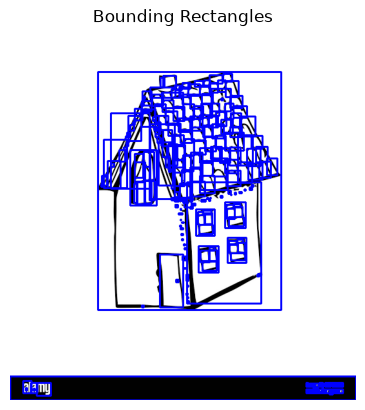

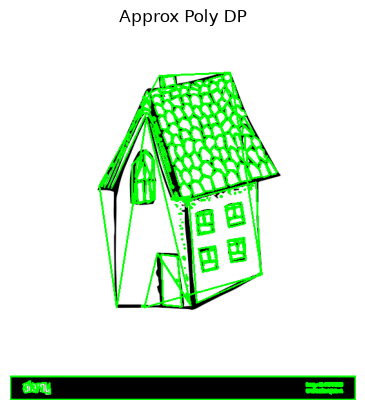

In [33]:
image = cv2.imread('house.png')
orig_image = image.copy()
plt.imshow(orig_image)
plt.title('Original Image')
plt.axis('off')
plt.show()

# Grayscale and binarize
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

# Find contours 
contours, hierarchy = cv2.findContours(thresh.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
copy = image.copy()

# Iterate through each contour 
for c in contours:
    x,y,w,h = cv2.boundingRect(c)
    cv2.rectangle(orig_image,(x,y),(x+w,y+h),(0,0,255),2)
    cv2.drawContours(image, [c], 0, (0, 255, 0), 2)

plt.imshow(image)
plt.title('Drawing of Contours')
plt.axis('off')
plt.show()

plt.imshow(orig_image)
plt.title('Bounding Rectangles')
plt.axis('off')
plt.show()

# Iterate through each contour and compute the approx contour
for c in contours:
    # Calculate accuracy as a percent of the contour perimeter
    accuracy = 0.03 * cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, accuracy, True)
    cv2.drawContours(copy, [approx], 0, (0, 255, 0), 2)

plt.imshow(copy)
plt.title('Approx Poly DP')
plt.axis('off')
plt.show()

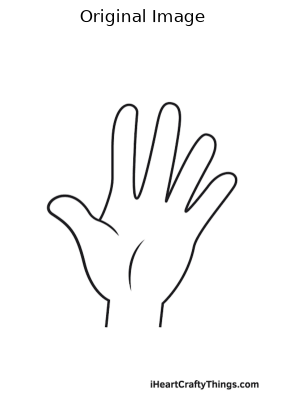

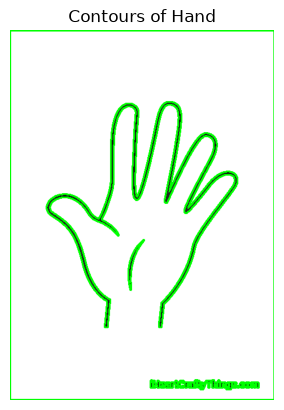

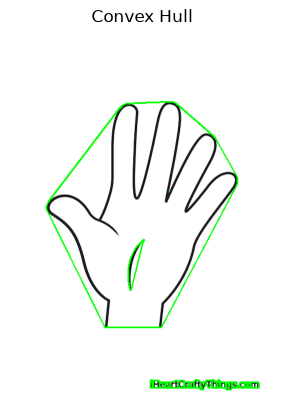

In [43]:
image = cv2.imread('hand.png')
orginal_image = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image)
plt.title('Original Image')
plt.axis('off')
plt.show()

# Threshold the image
ret, thresh = cv2.threshold(gray, 176, 255, 0)

# Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
cv2.drawContours(image, contours, -1, (0, 255, 0), 2)
plt.imshow(image)
plt.title('Contours of Hand')
plt.axis('off')
plt.show()


# Sort Contors by area and then remove the largest frame contour
n = len(contours) - 1
contours = sorted(contours, key=cv2.contourArea, reverse=False)[:n]

# Iterate through contours and draw the convex hull
for c in contours:
    hull = cv2.convexHull(c)
    cv2.drawContours(orginal_image, [hull], 0, (0, 255, 0), 2)

plt.imshow(orginal_image)
plt.title('Convex Hull')
plt.axis('off')
plt.show()